# Fake $Q-\chi$ posteriors

Let's simulate a number of BH charge $Q$ and spin $\chi$ posteriors, assuming the true values are drawn from a simple distribution. By cosmic censorship, the dimensionless parameters $Q$ and $\chi$ must satisfy $\sqrt{Q^2 + \chi^2} < 1$, or we would get a naked singularity. Since $0 \leq \chi < 1$ and $0 \leq Q < 1$ ($Q$ is the charge magnitude---we don't care about the sign), this defines a quarter-circle domain (a wedge).

One convenient way to work in this space is to switch to polar coordinates $r$ and $\theta$ such that, $Q = r \cos\theta$ and $\chi = r \sin \theta$. In terms of those quantities, the domain is specified by $0 \leq r < 1$ and $0 \leq \theta \leq \pi/2$.

We will simulate measurements as a follows. Assume that the true values of $r^{\rm true}_i$ and $\theta^{\rm true}_i$ for each event $i$ are drawn from (truncated) Gaussians such that

$$
r^{\rm true}_i \sim \mathcal{N}_{[0,1)}(\mu_r, \Sigma_r)~,~
\theta^{\rm true}_i \sim \mathcal{N}_{[0,\pi/2]}(\mu_\theta, \Sigma_\theta) ~.
$$

The Gaussians are truncated to the domain we specified above, as indicated by the subscripts. We will simulate individual-event posteriors also as Gaussians, with some characteristic observational uncertainties $\sigma_{r/\theta}$, i.e.,

$$
r_i \sim \mathcal{N}_{[0,1)}(r^{\rm true}_i, \sigma_r)~,~
\theta_i \sim \mathcal{N}_{[0,1)}(\theta^{\rm true}_i, \sigma_\theta) ~.
$$

I implement this model below with $\mu_r \rightarrow$ `r_mu_pop`, $\Sigma_r \rightarrow$ `r_sigma_pop`, $\sigma_r \rightarrow$ `r_sigma_obs` (and similar for $\theta \rightarrow $ `theta`).

In [3]:
%pylab inline
%config InlineBackend.figure_format = 'retina'

Populating the interactive namespace from numpy and matplotlib


In [4]:
from tqdm import tqdm
import seaborn as sns

sns.set_context('notebook')
sns.set_palette('colorblind')

In [54]:
# set the true values of the radius distribution, as well as the corresponding
# observational uncertainty
r_mu_pop = 0.8
r_sigma_pop = 0.5
r_sigma_obs = 0.1

# set the true values of the theta distribution, as well as the corresponding
# observational uncertainty
theta_mu_pop = pi/2
theta_sigma_pop = 0.01
theta_sigma_obs = pi/4

# set the number of events we will simulate
n_events = 10

# set the number of posterior samples to draw per event
n_samples = 1000

# define the edges of our domain
r_min, r_max = 0, 1
theta_min, theta_max = 0, pi/2

# whether to save samples to disk
save_samples = False

all_truths = []
all_samples = []
for i in tqdm(range(n_events)):
    # draw a true value of (r, theta) for this event (within the domain)
    r_true = -1
    while not (r_min <= r_true < r_max):
        r_true = np.random.normal(r_mu_pop, r_sigma_pop)
    
    theta_true = -1
    while not (theta_min <= theta_true < theta_max):
        theta_true = np.random.normal(theta_mu_pop, theta_sigma_pop)
    
    # draw an initial set of (r, theta) samples for this event
    r_obs_samples = np.random.normal(r_true, r_sigma_obs, n_samples)
    theta_obs_samples = np.random.normal(theta_true, theta_sigma_obs, n_samples)

    # now, make sure that all samples lie within the domain: iteratively 
    # replace samples that fall outside the boundary of the quarter-circle

    while any(r_obs_samples > r_max) or any(r_obs_samples < r_min):
        m = (r_obs_samples > r_max) | (r_obs_samples < r_min)
        r_obs_samples[m] = np.random.normal(r_true, r_sigma_obs, len(r_obs_samples[m]))

    while any(theta_obs_samples > theta_max) or any(theta_obs_samples < theta_min):
        m = (theta_obs_samples > theta_max) | (theta_obs_samples < theta_min)
        theta_obs_samples[m] = np.random.normal(theta_true, theta_sigma_obs, len(theta_obs_samples[m]))
    all_samples.append((r_obs_samples, theta_obs_samples))
    all_truths.append((r_true, theta_true))
    
    if save_samples:
        np.savetxt(f"r_theta_samples_event_{i}.txt", array((r_obs_samples, theta_obs_samples)).T)

100%|██████████| 10/10 [00:00<00:00, 1790.83it/s]


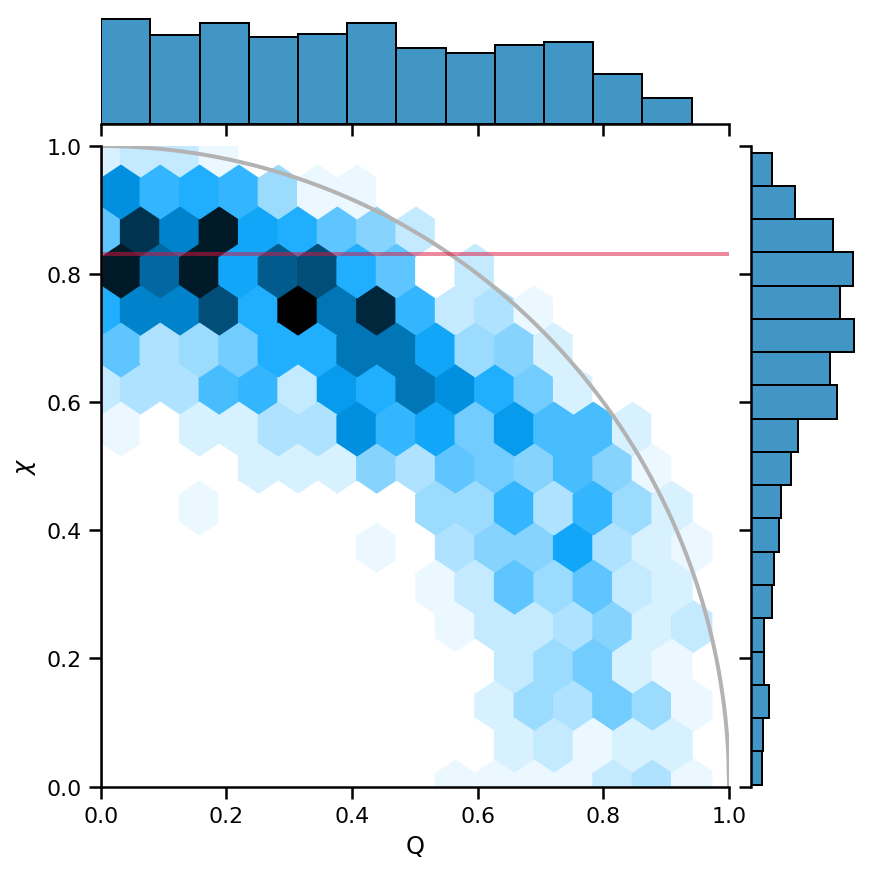

In [55]:
i = 0
r_obs_samples, theta_obs_samples = all_samples[i]
r_true, theta_true = all_truths[i]

# plot distribution
q_obs_samples = r_obs_samples*cos(theta_obs_samples)
chi_obs_samples = r_obs_samples*sin(theta_obs_samples)

g = sns.jointplot(x=q_obs_samples, y=chi_obs_samples, kind='hex', 
                  xlim=(0,1), ylim=(0,1))
x = linspace(0, 1, 1000)
g.ax_joint.plot(x, sqrt(1 - x**2), c='0.7', lw=2)
g.ax_joint.axvline(r_true*cos(theta_true), lw=2, c='crimson', alpha=0.5)
g.ax_joint.axhline(r_true*sin(theta_true), lw=2, c='crimson', alpha=0.5)
xlabel("Q")
ylabel(r"$\chi$");